
# TPC Digital Current → density / primary-density analysis v22

This is the DC successor to v20/v21. It keeps the synchronized-DC input and mapping paths from v21, but restores the important v20 analysis machinery:

- native-sector dead FEE / dead stripe / block / isolated-channel detection and recovery;
- sector-local smoothing, with measured and recovered products kept separately;
- robust radial and φ profiles, rather than using ROOT `ProjectionY` as a physics profile;
- \(1/r^\alpha\) fits using **standard R1 pads only by default**;
- a standard-R1 inward extrapolation retained as a QA model and compared directly with the antenna rings;
- parallel multi-run production and run-comparison plots;
- DC-density vs GEM-current, α vs GEM-current, run/reference ratios, and antenna/R1-response vs GEM-current;
- all four DC definitions (`raw`, `ped60_signed`, `ped60_positive`, `ped60_strict`) kept for bias studies.

## Important v22 fixes relative to v21

1. **R1 area bug fixed.** Standard R1 radial widths are derived only from standard R1 centers. They are no longer tied to the last antenna-ring center.
2. **Standard row area uses layer pitch**, matching the `IdealPadMap::get_layer_thickness` convention for first/last rows, rather than stretching a layer to a module boundary.
3. **φ mapping follows the current `IdealPadMap` side/sector transform**, including the side-1 pad reversal.
4. **Antenna extraction integrates the coarse global DC bins over each antenna collection cell** instead of sampling one global bin at the antenna-pad center.
5. Invalid/missing bins are written together with explicit coverage histograms. Use the saved robust profiles for radial fits, not ROOT `ProjectionY`.

The antenna response is still not absolutely gain-calibrated. The current DC preprocessing does not yet store a native antenna `ring × pad` histogram, so the antenna branch is an improved reconstruction from the global DC map. The notebook explicitly saves antenna/R1 extrapolation ratios so that their response can be studied versus GEM current before any calibration is imposed.


In [1]:

import ROOT as root
import numpy as np
import pandas as pd
import math, os, re, subprocess, json
from pathlib import Path
from array import array
from scipy import ndimage
from scipy.optimize import least_squares
from concurrent.futures import ThreadPoolExecutor, as_completed

root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)
root.gStyle.SetOptStat(0)

# ============================================================
# USER CONFIGURATION
# ============================================================

INPUT_ROOT = os.environ.get(
    "TPC_DC_INPUT",
    "input/dc0/dc_run00080858_win00.root"
)

MAPPING_DIR = Path("/home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/TPC/ChannelMapping1/PadPlane/")
GAIN_MAP_FILE = Path(os.environ.get(
    "TPC_DC_GAIN_MAP",
    "../distort/input/layer_gain_79513_Mariia_side01.root"
))

GAIN_MAP_HIST_SIDE0 = "hGainMap_side0_South"
GAIN_MAP_HIST_SIDE1 = "hGainMap_side1_North"
GAIN_LAYER_OFFSET = 7
APPLY_STANDARD_PAD_GAIN = True

DC_VARIANTS = ("raw", "ped60_signed", "ped60_positive", "ped60_strict")
MAIN_VARIANT = os.environ.get("TPC_DC_VARIANT", "ped60_signed")
DEFECT_VARIANT = os.environ.get("TPC_DC_DEFECT_VARIANT", "ped60_positive")
if MAIN_VARIANT not in DC_VARIANTS:
    raise ValueError(f"Unknown MAIN_VARIANT={MAIN_VARIANT}")
if DEFECT_VARIANT not in DC_VARIANTS:
    raise ValueError(f"Unknown DEFECT_VARIANT={DEFECT_VARIANT}")

N_SIDES, N_SECTORS, N_MODULES, LAYERS_PER_MODULE = 2, 12, 3, 16
N_PADS = {0:94, 1:128, 2:192}
PHI_MIN, PHI_MAX = -math.pi, math.pi
GLOBAL_PHI_BINS = 720
SOURCE_R_MIN_CM = 22.0
SOURCE_R_MAX_CM = 76.0
GLOBAL_DR_CM = 0.10

# Keep PHGarfield source range separately.
PHGARFIELD_R_MIN_CM = 22.8
PHGARFIELD_R_MAX_CM = 75.43

# ------------------------------------------------------------
# Native defect detection / recovery, inherited from v20
# ------------------------------------------------------------
MIN_EXPOSURE_FRACTION = 0.50
DEAD_CELL_REL_THRESHOLD = 0.18

MIN_DEAD_FEE_WIDTH = 2
DEAD_FEE_LAYER_FRACTION = 0.45
FEE_BRIDGE_PADS = 2
FEE_CONTEXT_PADS = 12
FEE_MIN_CONTEXT_CELLS = 4
FEE_CONTEXT_MEDIAN_LAYERS = 3
FEE_CONTEXT_GAUSS_SIGMA_LAYERS = 0.8

STRIPE_REL_THRESHOLD = 0.28
FULL_STRIPE_FRACTION = 0.70
HALF_STRIPE_FRACTION = 0.70
OTHER_HALF_MAX_DEAD_FRACTION = 0.35
STRIPE_NEIGHBOR_LAYERS = 3
ALLOW_R3_HALF_STRIPES = True

MIN_DEAD_BLOCK_WIDTH = 2
MIN_DEAD_BLOCK_LAYERS = 2
MIN_DEAD_BLOCK_CELLS = 6
BLOCK_CONTEXT_PADS = 12
BLOCK_CONTEXT_LAYERS = 3

REPAIR_SINGLE_OUTLIERS = True
SINGLE_DEAD_FACTOR = 0.25
SINGLE_HOT_FACTOR = 2.5
SINGLE_OUTLIER_PAD_RADIUS = 2
SINGLE_OUTLIER_LAYER_RADIUS = 1
SINGLE_OUTLIER_MIN_NEIGHBORS = 5
SINGLE_OUTLIER_PASSES = 2

SMOOTH_NATIVE_MAPS = True
SMOOTH_PAD_RADIUS = 2
SMOOTH_LAYER_RADIUS = 1
SMOOTH_BLEND = 0.75

ADC_ESTIMATOR = "trimmed_mean"
TRIM_FRACTION = 0.15
CLIP_OUTLIERS = True
CLIP_NSIGMA = 5.0

# ------------------------------------------------------------
# Radial fits / antenna QA
# ------------------------------------------------------------
ALPHA_BOUNDS = (0.0, 4.0)
ALPHA_INITIAL = 1.8
R1_FIT_N_LAYERS = 12
R1_FIT_RMIN_CM = 31.0
R1_FIT_RMAX_CM = 40.5
ALPHA_N_PHI_BINS = 12
MIN_PHI_PER_R = 40
FIT_USE_RECOVERED = True

ANTENNA_LOG_MAD_NSIGMA = 6.0
ANTENNA_MIN_EXPOSURE_FRACTION = 0.50
ANTENNA_REPAIR_PHI_RADIUS = 2
ANTENNA_REPAIR_RING_RADIUS = 1
ANTENNA_REPAIR_PASSES = 2

# ------------------------------------------------------------
# Output and batch
# ------------------------------------------------------------
def infer_run(path):
    m=re.search(r"run0*(\d{5})", str(path))
    return int(m.group(1)) if m else -1

RUN_NUMBER = infer_run(INPUT_ROOT)
RUN_TAG = os.environ.get("TPC_DC_TAG", f"run{RUN_NUMBER}" if RUN_NUMBER>0 else Path(INPUT_ROOT).stem)
IS_BATCH_CHILD = os.environ.get("TPC_DC_BATCH_CHILD", "0") == "1"

OUTPUT_DIR = Path(os.environ.get("TPC_DC_OUTPUT_DIR", "output_dc"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
QA_PLOT_DIR = OUTPUT_DIR / f"qa_v22_{RUN_TAG}"
QA_PLOT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_ROOT = OUTPUT_DIR / f"TPC_DC_primary_density_v22_{RUN_TAG}.root"
OUTPUT_SUMMARY = OUTPUT_DIR / f"TPC_DC_summary_v22_{RUN_TAG}.csv"

BATCH_INPUT_GLOB = os.environ.get(
    "TPC_DC_BATCH_GLOB",
    "dc_samples_run*/dc_run*_3samples.root"
)
BATCH_MAX_WORKERS = int(os.environ.get("TPC_DC_BATCH_WORKERS", "6"))
NOTEBOOK_FILE = Path(os.environ.get(
    "TPC_DC_NOTEBOOK",
    "TPC_IBF_PrimaryDensity_Extraction_v22_DC.ipynb"
))
REFERENCE_RUN = int(os.environ.get("TPC_DC_REFERENCE_RUN", "81558"))

print("Input:", INPUT_ROOT)
print("Run:", RUN_NUMBER)
print("Mapping:", MAPPING_DIR)
print("Gain map:", GAIN_MAP_FILE)
print("Main variant:", MAIN_VARIANT)
print("Defect-detection variant:", DEFECT_VARIANT)
print("Output:", OUTPUT_ROOT)


Welcome to JupyROOT 6.30/06
Input: input/dc0/dc_run00080858_win00.root
Run: 80858
Mapping: /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/TPC/ChannelMapping1/PadPlane
Gain map: ../distort/input/layer_gain_79513_Mariia_side01.root
Main variant: ped60_signed
Defect-detection variant: ped60_positive
Output: output_dc/TPC_DC_primary_density_v22_run80858.root



## 1. Mapping geometry

The standard 48 TPC rows and the four R1 antenna rings are kept as **separate radial systems**.

For a standard TPC row, the radial collection width is the local layer pitch:
- interior: half the distance between the neighboring row centers;
- first row: distance to the second row;
- last row: distance to the previous row.

This is the same first/last convention used by `IdealPadMap::get_layer_thickness`. It avoids the v21 problem where the first standard R1 layer was widened toward the last antenna ring.

For φ, the mapping CSV stores the local CDB pad φ. The global side/sector transformation below follows the current `IdealPadMap` convention.


In [2]:

def load_mapping(region):
    p = MAPPING_DIR / f"AutoPad-{region}-RevA.sch.ChannelMapping.csv"
    if not p.exists():
        raise FileNotFoundError(
            f"Missing {p}. Set TPC_DC_MAPPING_DIR to "
            "DC_ML_processing/1_dc_preprocessing."
        )
    df=pd.read_csv(p)
    required={"Radius","Pad","PadName","PadR","PadPhi","FEE","FEE_Chan"}
    missing=required-set(df.columns)
    if missing:
        raise KeyError(f"{p} missing columns {sorted(missing)}")
    return df

mapping={m:load_mapping(f"R{m+1}") for m in range(3)}

def wrap_phi(phi):
    return (np.asarray(phi)+math.pi)%(2*math.pi)-math.pi

def centered_widths(x):
    """Pitch-cell width around centers without coupling separate detector systems."""
    x=np.asarray(x,float)
    if len(x)<2:
        return np.ones_like(x)
    w=np.empty_like(x)
    w[1:-1]=0.5*(x[2:]-x[:-2])
    w[0]=x[1]-x[0]
    w[-1]=x[-1]-x[-2]
    return np.abs(w)

def circular_pitch_widths(phi):
    """Per-pad local angular pitch from ordered local pad centers."""
    p=np.unwrap(np.asarray(phi,float))
    return centered_widths(p)

def row_geometry(df, radius_index):
    r=df[df["Radius"]==radius_index].copy().sort_values("Pad")
    if r.empty:
        raise KeyError(f"No Radius={radius_index}")
    return {
        "radius_index":int(radius_index),
        "r_cm":float(np.mean(r["PadR"]))/10.0,
        "n_pads":len(r),
        "phi_local":r["PadPhi"].to_numpy(float),
        "local_pad":r["Pad"].to_numpy(int),
        "pad_name":r["PadName"].astype(str).to_numpy(),
        "fee":r["FEE"].to_numpy(int),
        "fee_chan":r["FEE_Chan"].to_numpy(int),
    }

zigzag_rows={m:[row_geometry(mapping[m],il) for il in range(16)] for m in range(3)}
antenna_rows=[row_geometry(mapping[0],il) for il in (-4,-3,-2,-1)]

# Standard radial widths are derived separately within R1/R2/R3.
for m in range(3):
    centers=np.array([r["r_cm"] for r in zigzag_rows[m]],float)
    widths=centered_widths(centers)
    for il,row in enumerate(zigzag_rows[m]):
        row["dr_cm"]=float(widths[il])
        row["rlo"]=row["r_cm"]-0.5*row["dr_cm"]
        row["rhi"]=row["r_cm"]+0.5*row["dr_cm"]
        row["dphi_pad"]=circular_pitch_widths(row["phi_local"])

# Antenna rings are a separate radial system. Do not couple outer antenna width to R1.
ant_centers=np.array([r["r_cm"] for r in antenna_rows],float)
ant_widths=centered_widths(ant_centers)
for ia,row in enumerate(antenna_rows):
    row["dr_cm"]=float(ant_widths[ia])
    row["rlo"]=row["r_cm"]-0.5*row["dr_cm"]
    row["rhi"]=row["r_cm"]+0.5*row["dr_cm"]
    row["dphi_pad"]=circular_pitch_widths(row["phi_local"])

def global_phi_for_pad(row, side, sector, pad_index):
    """
    Reproduce current IdealPadMap side/sector transformation using
    local CDB phi from the mapping file.
    """
    npads=row["n_pads"]
    lookup=pad_index if side==0 else npads-1-pad_index
    cdb_phi=float(row["phi_local"][lookup])
    mapped_sector=(5 + N_SECTORS - (sector % N_SECTORS)) % N_SECTORS
    phi=((1.0 if side==1 else -1.0)*(cdb_phi-math.pi/2.0)
         + mapped_sector*math.pi/6.0)
    return float(wrap_phi(phi))

def pad_area_cm2(row, pad_index):
    return row["r_cm"] * float(row["dphi_pad"][pad_index]) * row["dr_cm"]

print("Standard radial geometry:")
for m in range(3):
    rr=np.array([r["r_cm"] for r in zigzag_rows[m]])
    dr=np.array([r["dr_cm"] for r in zigzag_rows[m]])
    dp=np.concatenate([r["dphi_pad"] for r in zigzag_rows[m]])
    print(f" R{m+1}: r={rr[0]:.4f}..{rr[-1]:.4f} cm, "
          f"dr median={np.median(dr):.5f} cm, "
          f"dphi median={np.median(dp):.7f}")

print("Antenna radial geometry:")
for ia,row in enumerate(antenna_rows):
    print(f" A{ia}: r={row['r_cm']:.4f} cm, dr={row['dr_cm']:.4f} cm, "
          f"pads/sector={row['n_pads']}")

print("\nCritical v21 comparison:")
print(" first standard R1 dr in v22 =",zigzag_rows[0][0]["dr_cm"],"cm")
print(" nominal R1 pitch            =",zigzag_rows[0][1]["r_cm"]-zigzag_rows[0][0]["r_cm"],"cm")


Standard radial geometry:
 R1: r=31.4984..39.9852 cm, dr median=0.56599 cm, dphi median=0.0053073
 R2: r=41.6592..56.9695 cm, dr median=1.02069 cm, dphi median=0.0039592
 R3: r=58.9110..75.3667 cm, dr median=1.09705 cm, dphi median=0.0026514
Antenna radial geometry:
 A0: r=23.2776 cm, dr=2.2622 cm, pads/sector=8
 A1: r=25.5398 cm, dr=2.2622 cm, pads/sector=8
 A2: r=27.8020 cm, dr=2.2622 cm, pads/sector=8
 A3: r=30.0643 cm, dr=2.2622 cm, pads/sector=8

Critical v21 comparison:
 first standard R1 dr in v22 = 0.5630560144543253 cm
 nominal R1 pitch            = 0.5630560144543253 cm



## 2. Read synchronized DC ROOT input

Normal TPC rows use native `pad × layer` histograms. Antenna rings are reconstructed from the global `φ × r × frame` histograms because the present preprocessing does not yet write native antenna histograms.

Every DC quantity is normalized by its matching `nsamples` exposure.


In [3]:

fin=root.TFile.Open(str(INPUT_ROOT),"READ")
if not fin or fin.IsZombie():
    raise OSError(f"Cannot open {INPUT_ROOT}")

def th2_to_numpy(h):
    nx,ny=h.GetNbinsX(),h.GetNbinsY()
    z=np.empty((ny,nx),float)
    for iy in range(ny):
        for ix in range(nx):
            z[iy,ix]=h.GetBinContent(ix+1,iy+1)
    return z

def project_xy_numpy(h3):
    nr,nphi=h3.GetNbinsY(),h3.GetNbinsX()
    out=np.zeros((nr,nphi),float)
    for ir in range(1,nr+1):
        for ip in range(1,nphi+1):
            out[ir-1,ip-1]=sum(h3.GetBinContent(ip,ir,iz)
                               for iz in range(1,h3.GetNbinsZ()+1))
    redges=np.array(
        [h3.GetYaxis().GetBinLowEdge(i) for i in range(1,nr+1)]
        +[h3.GetYaxis().GetBinUpEdge(nr)],float)
    pedges=np.array(
        [h3.GetXaxis().GetBinLowEdge(i) for i in range(1,nphi+1)]
        +[h3.GetXaxis().GetBinUpEdge(nphi)],float)
    return out,redges,pedges

def safe_ratio(num,den):
    return np.divide(num,den,out=np.full_like(num,np.nan,dtype=float),
                     where=np.isfinite(den)&(den>0))

def global_name(variant,side):
    return f"h_dc_phi_r_frame_{variant}_side{side}"

def native_name(variant,side,sector,module):
    return f"h_dc_pad_vs_layer_{variant}_side{side}_sec{sector:02d}_R{module+1}"

global_dc={}
for side in range(2):
    h_exp=fin.Get(f"h_dc_nsamples_phi_r_frame_side{side}")
    h_cnt=fin.Get(f"h_dc_sampleblocks_phi_r_frame_side{side}")
    if not h_exp or not h_cnt:
        raise KeyError(f"Missing global DC exposure/count side {side}")
    exp,r_edges_mm,phi_edges_02pi=project_xy_numpy(h_exp)
    cnt,_,_=project_xy_numpy(h_cnt)
    item={
        "nsamples":exp,
        "sampleblocks":cnt,
        "r_edges_mm":r_edges_mm,
        "phi_edges_02pi":phi_edges_02pi,
    }
    for variant in DC_VARIANTS:
        h=fin.Get(global_name(variant,side))
        if not h:
            raise KeyError(global_name(variant,side))
        q,_,_=project_xy_numpy(h)
        item[variant]=q
        item[f"{variant}_rate"]=safe_ratio(q,exp)
    global_dc[side]=item

native_dc={}
for side in range(2):
    for sector in range(12):
        for module in range(3):
            he=fin.Get(f"h_dc_nsamples_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}")
            hc=fin.Get(f"h_dc_sampleblocks_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}")
            if not he or not hc:
                raise KeyError(f"Missing native exposure/count s{side} sec{sector} R{module+1}")
            exp=th2_to_numpy(he)
            cnt=th2_to_numpy(hc)
            item={"nsamples":exp,"sampleblocks":cnt}
            for variant in DC_VARIANTS:
                h=fin.Get(native_name(variant,side,sector,module))
                if not h:
                    raise KeyError(native_name(variant,side,sector,module))
                q=th2_to_numpy(h)
                item[variant]=q
                item[f"{variant}_rate"]=safe_ratio(q,exp)
            native_dc[(side,module,sector)]=item

def norm_value(side,label):
    h=fin.Get("h_dc_norm")
    if not h:
        return np.nan
    iy=next((i for i in range(1,h.GetNbinsY()+1)
             if h.GetYaxis().GetBinLabel(i)==label),None)
    return h.GetBinContent(side+1,iy) if iy else np.nan

LIVE_FRAME_SLOTS=np.array([norm_value(s,"LIVE_FRAME_SLOTS") for s in range(2)])
LIVE_BCO_TICKS=np.array([norm_value(s,"LIVE_BCO_TICKS") for s in range(2)])

pGem=fin.Get("p_dc_gem_r1_current")
RUN_GEM_CURRENT=np.array([
    pGem.GetBinContent(1) if pGem else np.nan,
    pGem.GetBinContent(2) if pGem else np.nan
],float)

print("Live frame slots:",LIVE_FRAME_SLOTS)
print("R1 GEM current/load [South,North]:",RUN_GEM_CURRENT)

# Exposure masks are shared across all variants.
native_low_exposure={}
for key,item in native_dc.items():
    exp=item["nsamples"]
    good=exp[np.isfinite(exp)&(exp>0)]
    ref=float(np.median(good)) if len(good) else np.nan
    bad=(~np.isfinite(exp))|(exp<=0)
    if np.isfinite(ref):
        bad |= exp < MIN_EXPOSURE_FRACTION*ref
    native_low_exposure[key]=bad

fin.Close()


Live frame slots: [3000. 3000.]
R1 GEM current/load [South,North]: [13.80696487 13.52348614]



## 3. v20 dead-FEE / stripe / block detection and recovery

Defects are classified in native sector coordinates before any global \(r,\phi\) remapping. Low-exposure cells are excluded from the reference population.

The same structural masks are applied to every DC variant so signed/positive/strict comparisons are not biased by using different detector masks.


In [4]:

def robust_scale(x):
    x=np.asarray(x,float)
    x=x[np.isfinite(x)]
    if not len(x):
        return 0.0
    med=np.median(x)
    mad=np.median(np.abs(x-med))
    return 1.4826*mad if mad>0 else np.std(x)

def clipped_values(x):
    x=np.asarray(x,float)
    x=x[np.isfinite(x)]
    if not len(x):
        return x
    med=np.median(x); sig=robust_scale(x)
    if CLIP_OUTLIERS and np.isfinite(sig) and sig>0:
        x=x[np.abs(x-med)<=CLIP_NSIGMA*sig]
    return x

def estimate_values(x,mode=None):
    mode=ADC_ESTIMATOR if mode is None else mode
    x=clipped_values(x)
    if not len(x):
        return np.nan
    if mode in ("raw","mean"):
        return float(np.mean(x))
    if mode=="sum":
        return float(np.sum(x))
    if mode=="median":
        return float(np.median(x))
    if mode=="trimmed_mean":
        xs=np.sort(x)
        ntrim=int(TRIM_FRACTION*len(xs))
        if 2*ntrim>=len(xs):
            return float(np.median(xs))
        return float(np.mean(xs[ntrim:len(xs)-ntrim]))
    raise ValueError(mode)

def contiguous_true_regions(mask):
    mask=np.asarray(mask,bool)
    out=[]; start=None
    for i,v in enumerate(mask):
        if v and start is None:
            start=i
        elif not v and start is not None:
            out.append((start,i)); start=None
    if start is not None:
        out.append((start,len(mask)))
    return out

def robust_dead_cell_candidates(adc):
    adc=np.asarray(adc,float)
    pos=np.where(np.isfinite(adc)&(adc>0),adc,np.nan)
    row=np.nanmedian(pos,axis=1)
    col=np.nanmedian(pos,axis=0)
    glob=np.nanmedian(pos)
    row=np.where(np.isfinite(row),row,glob)
    col=np.where(np.isfinite(col),col,glob)
    expected=np.maximum(row[:,None],col[None,:])
    candidate=(~np.isfinite(adc)) | (
        np.isfinite(expected)&(expected>0)&
        (adc<DEAD_CELL_REL_THRESHOLD*expected)
    )
    return candidate,expected

def radial_dead_fraction(adc,il):
    rows=[j for d in range(1,STRIPE_NEIGHBOR_LAYERS+1)
          for j in (il-d,il+d) if 0<=j<adc.shape[0]]
    if not rows:
        return np.zeros(adc.shape[1],bool)
    ref=np.nanmedian(
        np.where(np.asarray(adc[rows])>0,adc[rows],np.nan),axis=0
    )
    return (~np.isfinite(adc[il])) | (
        np.isfinite(ref)&(ref>0)&(adc[il]<STRIPE_REL_THRESHOLD*ref)
    )

def detect_dead_structures(adc,module,low_exposure=None):
    work=np.asarray(adc,float).copy()
    if low_exposure is not None:
        work[np.asarray(low_exposure,bool)]=np.nan

    candidate,expected=robust_dead_cell_candidates(work)
    nlayer,npad=work.shape
    mid=npad//2

    colfrac=np.mean(candidate,axis=0)
    fee_cols=colfrac>=DEAD_FEE_LAYER_FRACTION
    if FEE_BRIDGE_PADS>0:
        fee_cols=ndimage.binary_closing(
            fee_cols,structure=np.ones(2*FEE_BRIDGE_PADS+1)
        )
    fee_regions=[
        x for x in contiguous_true_regions(fee_cols)
        if x[1]-x[0]>=MIN_DEAD_FEE_WIDTH
    ]
    fee_region_mask=np.zeros_like(candidate)
    for lo,hi in fee_regions:
        fee_region_mask[:,lo:hi]=True
    fee_mask=fee_region_mask&candidate

    stripe_full=np.zeros_like(candidate)
    stripe_half=np.zeros_like(candidate)
    stripe_details=[]
    for il in range(nlayer):
        dead=radial_dead_fraction(work,il)
        usable=~fee_region_mask[il]
        if low_exposure is not None:
            usable &= ~np.asarray(low_exposure,bool)[il]
        if np.count_nonzero(usable)<4:
            continue

        frac=np.count_nonzero(dead&usable)/np.count_nonzero(usable)
        if frac>=FULL_STRIPE_FRACTION:
            stripe_full[il,usable]=True
            stripe_details.append(("full",il,float(frac)))
            continue

        if module==2 and ALLOW_R3_HALF_STRIPES:
            left=usable[:mid]; right=usable[mid:]
            lf=np.count_nonzero(dead[:mid]&left)/max(np.count_nonzero(left),1)
            rf=np.count_nonzero(dead[mid:]&right)/max(np.count_nonzero(right),1)
            if lf>=HALF_STRIPE_FRACTION and rf<=OTHER_HALF_MAX_DEAD_FRACTION:
                stripe_half[il,:mid]=left
                stripe_details.append(("half-left",il,float(lf)))
            elif rf>=HALF_STRIPE_FRACTION and lf<=OTHER_HALF_MAX_DEAD_FRACTION:
                stripe_half[il,mid:]=right
                stripe_details.append(("half-right",il,float(rf)))

    already=fee_mask|stripe_full|stripe_half
    remaining=candidate&~already
    labels,nlab=ndimage.label(remaining,structure=np.ones((3,3),int))
    block=np.zeros_like(candidate)
    block_details=[]
    for lab in range(1,nlab+1):
        yy,xx=np.where(labels==lab)
        if not len(xx):
            continue
        width=xx.max()-xx.min()+1
        height=yy.max()-yy.min()+1
        if (width>=MIN_DEAD_BLOCK_WIDTH and
            height>=MIN_DEAD_BLOCK_LAYERS and
            len(xx)>=MIN_DEAD_BLOCK_CELLS):
            block[yy,xx]=True
            block_details.append((
                int(yy.min()),int(yy.max()+1),
                int(xx.min()),int(xx.max()+1),int(len(xx))
            ))

    return {
        "candidate":candidate,
        "expected":expected,
        "fee":fee_mask,
        "fee_regions":fee_regions,
        "fee_region_mask":fee_region_mask,
        "stripe_full":stripe_full,
        "stripe_half":stripe_half,
        "stripe":stripe_full|stripe_half,
        "stripe_details":stripe_details,
        "block":block,
        "block_details":block_details,
        "col_dead_fraction":colfrac,
        "low_exposure":np.zeros_like(candidate) if low_exposure is None else np.asarray(low_exposure,bool),
    }

auto_masks={}
for key,item in native_dc.items():
    det=item[f"{DEFECT_VARIANT}_rate"].copy()
    auto_masks[key]=detect_dead_structures(det,key[1],native_low_exposure[key])

print("Dead-FEE regions:",sum(len(v["fee_regions"]) for v in auto_masks.values()))
print("Dead stripes:",sum(len(v["stripe_details"]) for v in auto_masks.values()))
print("Large dead blocks:",sum(len(v["block_details"]) for v in auto_masks.values()))
print("Low-exposure cells:",sum(np.count_nonzero(v["low_exposure"]) for v in auto_masks.values()))


/tmp/ipykernel_31376/643175265.py:54: RuntimeWarning: All-NaN slice encountered
  row=np.nanmedian(pos,axis=1)
/tmp/ipykernel_31376/643175265.py:55: RuntimeWarning: All-NaN slice encountered
  col=np.nanmedian(pos,axis=0)
/tmp/ipykernel_31376/643175265.py:71: RuntimeWarning: All-NaN slice encountered
  ref=np.nanmedian(


Dead-FEE regions: 30
Dead stripes: 1
Large dead blocks: 144
Low-exposure cells: 18480


In [5]:

def local_robust_value(arr,il,ip,pad_radius,layer_radius,exclude=None):
    vals=[]
    for jl in range(max(0,il-layer_radius),min(arr.shape[0],il+layer_radius+1)):
        for jp in range(max(0,ip-pad_radius),min(arr.shape[1],ip+pad_radius+1)):
            if jl==il and jp==ip:
                continue
            if exclude is not None and exclude[jl,jp]:
                continue
            v=arr[jl,jp]
            if np.isfinite(v) and v>0:
                vals.append(v)
    return estimate_values(vals,"trimmed_mean") if len(vals)>=SINGLE_OUTLIER_MIN_NEIGHBORS else np.nan

def repair_fee_regions(adc,fee_mask,fee_regions,protected):
    out=adc.copy().astype(float)
    for lo,hi in fee_regions:
        for il,ip0 in zip(*np.where(fee_mask[:,lo:hi])):
            ip=ip0+lo
            left=[out[il,p] for p in range(max(0,lo-FEE_CONTEXT_PADS),lo)
                  if not protected[il,p] and np.isfinite(out[il,p]) and out[il,p]>0]
            right=[out[il,p] for p in range(hi,min(out.shape[1],hi+FEE_CONTEXT_PADS))
                   if not protected[il,p] and np.isfinite(out[il,p]) and out[il,p]>0]
            lv=estimate_values(left,"trimmed_mean")
            rv=estimate_values(right,"trimmed_mean")
            if np.isfinite(lv) and np.isfinite(rv):
                t=(ip-lo+1)/(hi-lo+1)
                out[il,ip]=(1-t)*lv+t*rv
            elif np.isfinite(lv):
                out[il,ip]=lv
            elif np.isfinite(rv):
                out[il,ip]=rv
    return out

def repair_mask_from_context(adc,mask,protected):
    out=adc.copy().astype(float)
    for il,ip in zip(*np.where(mask)):
        v=local_robust_value(out,il,ip,BLOCK_CONTEXT_PADS,BLOCK_CONTEXT_LAYERS,protected|mask)
        if np.isfinite(v):
            out[il,ip]=v
    return out

def recover_stripes(adc,stripe_mask,other_bad):
    out=adc.copy().astype(float)
    for il,ip in zip(*np.where(stripe_mask)):
        vals=[]
        for d in range(1,STRIPE_NEIGHBOR_LAYERS+1):
            for jl in (il-d,il+d):
                if 0<=jl<out.shape[0] and not other_bad[jl,ip]:
                    v=out[jl,ip]
                    if np.isfinite(v) and v>0:
                        vals.append(v)
        if vals:
            out[il,ip]=estimate_values(vals,"trimmed_mean")
        else:
            v=local_robust_value(
                out,il,ip,2,STRIPE_NEIGHBOR_LAYERS,
                other_bad|stripe_mask
            )
            if np.isfinite(v):
                out[il,ip]=v
    return out

def repair_single_outliers(adc,protected):
    out=adc.copy().astype(float)
    for _ in range(SINGLE_OUTLIER_PASSES):
        new=out.copy(); changed=0
        for il in range(out.shape[0]):
            for ip in range(out.shape[1]):
                if protected[il,ip]:
                    continue
                ref=local_robust_value(
                    out,il,ip,SINGLE_OUTLIER_PAD_RADIUS,
                    SINGLE_OUTLIER_LAYER_RADIUS,protected
                )
                if not np.isfinite(ref) or ref<=0:
                    continue
                v=out[il,ip]
                bad=(not np.isfinite(v)) or v<=0 or \
                    v<SINGLE_DEAD_FACTOR*ref or v>SINGLE_HOT_FACTOR*ref
                if bad:
                    new[il,ip]=ref
                    changed+=1
        out=new
        if changed==0:
            break
    return out

def robust_smooth_native(adc):
    if not SMOOTH_NATIVE_MAPS:
        return adc.copy()
    out=adc.copy().astype(float)
    sm=out.copy()
    for il in range(out.shape[0]):
        for ip in range(out.shape[1]):
            vals=[]
            for jl in range(max(0,il-SMOOTH_LAYER_RADIUS),
                            min(out.shape[0],il+SMOOTH_LAYER_RADIUS+1)):
                for jp in range(max(0,ip-SMOOTH_PAD_RADIUS),
                                min(out.shape[1],ip+SMOOTH_PAD_RADIUS+1)):
                    v=out[jl,jp]
                    if np.isfinite(v) and v>0:
                        vals.append(v)
            ref=estimate_values(vals,"trimmed_mean")
            if np.isfinite(ref):
                sm[il,ip]=(1-SMOOTH_BLEND)*out[il,ip]+SMOOTH_BLEND*ref
    return sm

def recover_native_variant(variant):
    measured={}
    recovered={}
    repaired_mask={}
    unstable_mask={}
    for key,item in native_dc.items():
        raw=item[f"{variant}_rate"].astype(float).copy()
        low=auto_masks[key]["low_exposure"]
        measured[key]=raw.copy()

        # Exclude missing exposure from reconstruction input.
        raw[low]=np.nan
        m=auto_masks[key]
        stripe=m["stripe"]
        other_bad=m["fee"]|m["block"]|low

        a=repair_fee_regions(raw,m["fee"],m["fee_regions"],stripe|m["block"]|low)
        a=repair_mask_from_context(a,m["block"],stripe|m["fee"]|low)
        a=recover_stripes(a,stripe,other_bad)

        if REPAIR_SINGLE_OUTLIERS:
            a=repair_single_outliers(a,low)

        a=robust_smooth_native(a)

        recovered[key]=a
        repaired_mask[key]=m["fee"]|m["block"]
        unstable_mask[key]=m["fee"]|m["block"]|m["stripe"]|low
    return measured,recovered,repaired_mask,unstable_mask

native_products={}
for variant in DC_VARIANTS:
    native_products[variant]=recover_native_variant(variant)

print("Recovered native maps for:",", ".join(DC_VARIANTS))


Recovered native maps for: raw, ped60_signed, ped60_positive, ped60_strict



## 4. Gain map and standard-pad global density maps

For every native standard pad:

\[
\rho_{\rm DC} = \frac{Q/N_{\rm samples}}{r\,\Delta r\,\Delta\phi},
\qquad
\rho_{\rm primary} = \frac{\rho_{\rm DC}}{G_{\rm sector,layer}}.
\]

Measured and recovered maps are both retained. Coverage, repair fraction, and unstable fraction are propagated to the global map.


In [6]:

gain_hist={}
if APPLY_STANDARD_PAD_GAIN:
    fg=root.TFile.Open(str(GAIN_MAP_FILE),"READ")
    if not fg or fg.IsZombie():
        raise OSError(f"Cannot open gain map {GAIN_MAP_FILE}")
    for side,name in [(0,GAIN_MAP_HIST_SIDE0),(1,GAIN_MAP_HIST_SIDE1)]:
        h=fg.Get(name)
        if not h:
            raise KeyError(name)
        h=h.Clone(name+"_clone")
        h.SetDirectory(0)
        gain_hist[side]=h
    fg.Close()

def gain_for(side,sector,module,local_layer):
    if not APPLY_STANDARD_PAD_GAIN:
        return 1.0
    glayer=7+16*module+local_layer
    h=gain_hist[side]
    bx=h.GetXaxis().FindBin(sector+0.5)
    by=h.GetYaxis().FindBin((glayer-GAIN_LAYER_OFFSET)+0.5)
    g=float(h.GetBinContent(bx,by))
    return g if np.isfinite(g) and g>0 else np.nan

phi_edges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
phi_centers=0.5*(phi_edges[:-1]+phi_edges[1:])
r_edges=np.arange(SOURCE_R_MIN_CM,SOURCE_R_MAX_CM+GLOBAL_DR_CM*1.001,GLOBAL_DR_CM)
if r_edges[-1]<SOURCE_R_MAX_CM:
    r_edges=np.r_[r_edges,SOURCE_R_MAX_CM]
r_edges[-1]=SOURCE_R_MAX_CM
r_centers=0.5*(r_edges[:-1]+r_edges[1:])
GRID_SHAPE=(len(r_centers),len(phi_centers))

def circular_delta(a,b):
    return np.arctan2(np.sin(a-b),np.cos(a-b))

def cell_bins(rlo,rhi,phi_center,dphi):
    ir=np.where((r_centers>=rlo)&(r_centers<rhi))[0]
    ip=np.where(np.abs(circular_delta(phi_centers,phi_center))<=0.5*dphi)[0]
    return ir,ip

def accumulate_cell(sum_map,count_map,value,rlo,rhi,phi,dphi,weight=1.0):
    if not np.isfinite(value):
        return
    ir,ip=cell_bins(rlo,rhi,phi,dphi)
    if not len(ir) or not len(ip):
        return
    sum_map[np.ix_(ir,ip)] += value*weight
    count_map[np.ix_(ir,ip)] += weight

def build_standard_global(side,variant,native_maps,repaired_mask,unstable_mask):
    dc_sum=np.zeros(GRID_SHAPE)
    pr_sum=np.zeros(GRID_SHAPE)
    count=np.zeros(GRID_SHAPE)
    repaired_sum=np.zeros(GRID_SHAPE)
    unstable_sum=np.zeros(GRID_SHAPE)

    for module in range(3):
        for sector in range(12):
            key=(side,module,sector)
            a=native_maps[key]
            rep=repaired_mask[key]
            unst=unstable_mask[key]

            for il,row in enumerate(zigzag_rows[module]):
                g=gain_for(side,sector,module,il)
                for ip in range(row["n_pads"]):
                    v=a[il,ip]
                    if not np.isfinite(v):
                        continue
                    dphi=float(row["dphi_pad"][ip])
                    area=pad_area_cm2(row,ip)
                    rho=v/area
                    prho=rho/g if np.isfinite(g) and g>0 else np.nan
                    phi=global_phi_for_pad(row,side,sector,ip)

                    ir,ib=cell_bins(row["rlo"],row["rhi"],phi,dphi)
                    if not len(ir) or not len(ib):
                        continue
                    dc_sum[np.ix_(ir,ib)] += rho
                    if np.isfinite(prho):
                        pr_sum[np.ix_(ir,ib)] += prho
                    count[np.ix_(ir,ib)] += 1.0
                    repaired_sum[np.ix_(ir,ib)] += float(rep[il,ip])
                    unstable_sum[np.ix_(ir,ib)] += float(unst[il,ip])

    def average(s):
        out=np.full(GRID_SHAPE,np.nan)
        good=count>0
        out[good]=s[good]/count[good]
        return out

    return {
        "dc":average(dc_sum),
        "primary":average(pr_sum),
        "coverage":count,
        "repair_fraction":average(repaired_sum),
        "unstable_fraction":average(unstable_sum),
    }

standard_maps={}
for variant in DC_VARIANTS:
    measured,recovered,rep,unst=native_products[variant]
    standard_maps[variant]={"measured":{},"recovered":{}}
    for side in range(2):
        standard_maps[variant]["measured"][side]=build_standard_global(
            side,variant,measured,rep,unst
        )
        standard_maps[variant]["recovered"][side]=build_standard_global(
            side,variant,recovered,rep,unst
        )

print("Built standard-pad global maps for all variants.")


Built standard-pad global maps for all variants.



## 5. Antenna rings: area-integrated extraction and recovery

v21 sampled a single coarse global DC bin at each antenna-pad center. v22 instead **integrates all coarse global bins whose centers fall inside the antenna collection cell**, separately summing charge and exposure:

\[
\bar Q_{\rm antenna} =
\frac{\sum_{\rm cell}Q}{\sum_{\rm cell}N_{\rm samples}}.
\]

The four antenna rings are treated as their own radial-pitch system. Their response is **not** divided by the normal 48-layer gain map.

A ring/φ robust outlier mask and local recovery are applied, while both measured and recovered antenna products are saved. This is still provisional until native antenna histograms are added to the C++ preprocessing.


In [7]:

def global_cell_integral(item,arrname,rlo,rhi,phi_center,dphi):
    """
    Integrate global coarse bins by bin-center membership inside one antenna cell.
    r is stored in mm, phi in [0,2pi).
    """
    redges=item["r_edges_mm"]/10.0
    rcen=0.5*(redges[:-1]+redges[1:])
    pedges=item["phi_edges_02pi"]
    pcen=0.5*(pedges[:-1]+pedges[1:])
    pcen_wrapped=wrap_phi(pcen)

    ir=np.where((rcen>=rlo)&(rcen<rhi))[0]
    ip=np.where(np.abs(circular_delta(pcen_wrapped,phi_center))<=0.5*dphi)[0]
    if not len(ir) or not len(ip):
        return np.nan,0
    vals=item[arrname][np.ix_(ir,ip)]
    return float(np.nansum(vals)), int(vals.size)

def build_antenna_records(side):
    gitem=global_dc[side]
    rows=[]
    for ia,row in enumerate(antenna_rows):
        for sector in range(12):
            for ip in range(row["n_pads"]):
                phi=global_phi_for_pad(row,side,sector,ip)
                dphi=float(row["dphi_pad"][ip])
                area=pad_area_cm2(row,ip)

                exp,nbin=global_cell_integral(
                    gitem,"nsamples",row["rlo"],row["rhi"],phi,dphi
                )
                cnt,_=global_cell_integral(
                    gitem,"sampleblocks",row["rlo"],row["rhi"],phi,dphi
                )

                rec={
                    "ring":ia,
                    "sector":sector,
                    "pad":ip,
                    "phi":phi,
                    "r_cm":row["r_cm"],
                    "rlo":row["rlo"],
                    "rhi":row["rhi"],
                    "dphi":dphi,
                    "area_cm2":area,
                    "nsamples":exp,
                    "sampleblocks":cnt,
                    "global_bins":nbin,
                }
                for variant in DC_VARIANTS:
                    q,_=global_cell_integral(
                        gitem,variant,row["rlo"],row["rhi"],phi,dphi
                    )
                    rate=q/exp if np.isfinite(exp) and exp>0 else np.nan
                    rec[f"{variant}_rate"]=rate
                    rec[f"{variant}_density"]=rate/area if np.isfinite(rate) else np.nan
                rows.append(rec)
    return pd.DataFrame(rows)

antenna_df={s:build_antenna_records(s) for s in range(2)}

def antenna_mask_and_recover(df,variant):
    d=df.copy().sort_values(["ring","phi"]).reset_index(drop=True)
    density=d[f"{variant}_density"].to_numpy(float)
    exp=d["nsamples"].to_numpy(float)

    bad=(~np.isfinite(exp))|(exp<=0)|(~np.isfinite(density))

    # Exposure relative to each ring.
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        goodexp=exp[idx][np.isfinite(exp[idx])&(exp[idx]>0)]
        if len(goodexp):
            eref=np.median(goodexp)
            bad[idx] |= exp[idx] < ANTENNA_MIN_EXPOSURE_FRACTION*eref

    # signed pedestal pathology is useful even when another variant is being studied
    signed=d["ped60_signed_rate"].to_numpy(float)
    bad |= np.isfinite(signed)&(signed<0)

    # Loose robust ring-level outlier rejection.
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        vals=density[idx]
        good=np.isfinite(vals)&(vals>0)&(~bad[idx])
        if np.count_nonzero(good)<8:
            continue
        lv=np.log(vals[good])
        med=np.median(lv)
        mad=1.4826*np.median(np.abs(lv-med))
        if mad<=0:
            continue
        local_bad=np.zeros(len(idx),bool)
        local_bad[good]=np.abs(np.log(vals[good])-med)>ANTENNA_LOG_MAD_NSIGMA*mad
        bad[idx[local_bad]]=True

    # Recover in a 4 x Nphi representation, preserving circular phi.
    phis=np.sort(d["phi"].unique())
    # Unique exact phi values need not align across rings, so use rank within each ring.
    ring_arrays=[]
    ring_bad=[]
    ring_indices=[]
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        idx=idx[np.argsort(d.loc[idx,"phi"].to_numpy())]
        ring_indices.append(idx)
        ring_arrays.append(density[idx].copy())
        ring_bad.append(bad[idx].copy())

    nphi=min(len(x) for x in ring_arrays)
    arr=np.vstack([x[:nphi] for x in ring_arrays])
    msk=np.vstack([x[:nphi] for x in ring_bad])
    out=arr.copy()

    for _ in range(ANTENNA_REPAIR_PASSES):
        new=out.copy()
        changed=0
        for ir in range(4):
            for ip in range(nphi):
                if not msk[ir,ip]:
                    continue
                vals=[]
                for dr in range(-ANTENNA_REPAIR_RING_RADIUS,ANTENNA_REPAIR_RING_RADIUS+1):
                    jr=ir+dr
                    if jr<0 or jr>=4:
                        continue
                    for dp in range(-ANTENNA_REPAIR_PHI_RADIUS,ANTENNA_REPAIR_PHI_RADIUS+1):
                        jp=(ip+dp)%nphi
                        if jr==ir and jp==ip:
                            continue
                        if msk[jr,jp]:
                            continue
                        v=out[jr,jp]
                        if np.isfinite(v) and v>0:
                            vals.append(v)
                ref=estimate_values(vals,"trimmed_mean")
                if np.isfinite(ref):
                    new[ir,ip]=ref
                    changed+=1
        out=new
        if changed==0:
            break

    recovered=density.copy()
    for ring in range(4):
        idx=ring_indices[ring][:nphi]
        recovered[idx]=out[ring]

    return bad,recovered

antenna_products={}
for variant in DC_VARIANTS:
    antenna_products[variant]={}
    for side in range(2):
        bad,recovered=antenna_mask_and_recover(antenna_df[side],variant)
        antenna_products[variant][side]={
            "bad":bad,
            "measured":antenna_df[side][f"{variant}_density"].to_numpy(float),
            "recovered":recovered,
        }

for side in range(2):
    print(f"\nAntenna side {side}")
    d=antenna_df[side]
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        vals=antenna_products[MAIN_VARIANT][side]["recovered"][idx]
        nbad=np.count_nonzero(antenna_products[MAIN_VARIANT][side]["bad"][idx])
        print(f" ring {ring}: r={np.median(d.loc[idx,'r_cm']):.3f} cm, "
              f"median recovered={np.nanmedian(vals):.6g}, masked={nbad}/{len(idx)}, "
              f"global bins/pad median={np.median(d.loc[idx,'global_bins']):.1f}")



Antenna side 0
 ring 0: r=23.278 cm, median recovered=61.844, masked=24/96, global bins/pad median=6.0
 ring 1: r=25.540 cm, median recovered=56.2962, masked=24/96, global bins/pad median=8.0
 ring 2: r=27.802 cm, median recovered=53.018, masked=39/96, global bins/pad median=8.0
 ring 3: r=30.064 cm, median recovered=50.2321, masked=24/96, global bins/pad median=8.0

Antenna side 1
 ring 0: r=23.278 cm, median recovered=62.5333, masked=8/96, global bins/pad median=6.0
 ring 1: r=25.540 cm, median recovered=57.4321, masked=16/96, global bins/pad median=8.0
 ring 2: r=27.802 cm, median recovered=53.458, masked=9/96, global bins/pad median=8.0
 ring 3: r=30.064 cm, median recovered=50.8575, masked=25/96, global bins/pad median=8.0



## 6. Combine standard and antenna maps

The standard-pad map remains the calibrated primary-density proxy. Antenna bins are kept as an uncalibrated low-r extension and explicitly tagged with an antenna mask.

For physics fits, the notebook uses standard R1 by default. Antenna points are compared against the standard-R1 extrapolation rather than forcing them into the fit.


In [8]:

def antenna_to_grid(side,variant,mode):
    d=antenna_df[side]
    vals=antenna_products[variant][side][mode]
    sm=np.zeros(GRID_SHAPE)
    cnt=np.zeros(GRID_SHAPE)
    mask=np.zeros(GRID_SHAPE,bool)

    for i,rec in d.iterrows():
        v=vals[i]
        if not np.isfinite(v):
            continue
        ir,ip=cell_bins(
            float(rec.rlo),float(rec.rhi),
            float(rec.phi),float(rec.dphi)
        )
        if not len(ir) or not len(ip):
            continue
        sm[np.ix_(ir,ip)] += v
        cnt[np.ix_(ir,ip)] += 1
        mask[np.ix_(ir,ip)] = True

    out=np.full(GRID_SHAPE,np.nan)
    good=cnt>0
    out[good]=sm[good]/cnt[good]
    return out,cnt,mask

combined_maps={}
for variant in DC_VARIANTS:
    combined_maps[variant]={"measured":{},"recovered":{}}
    for mode in ("measured","recovered"):
        for side in range(2):
            std=standard_maps[variant][mode][side]
            dc=std["dc"].copy()
            primary=std["primary"].copy()
            coverage=std["coverage"].copy()

            ant,acov,amask=antenna_to_grid(side,variant,mode)
            take=np.isfinite(ant)&(~np.isfinite(dc))
            dc[take]=ant[take]
            # antenna has no normal gain correction
            primary[take]=ant[take]
            coverage[take]=acov[take]

            combined_maps[variant][mode][side]={
                "dc":dc,
                "primary":primary,
                "coverage":coverage,
                "antenna_mask":amask,
                "repair_fraction":std["repair_fraction"],
                "unstable_fraction":std["unstable_fraction"],
            }

print("Combined standard + antenna maps built.")


Combined standard + antenna maps built.



## 7. Robust profiles and \(1/r^\alpha\) QA

The radial profile is a robust median over **covered, finite φ bins**, not a ROOT projection.

The main α fit uses standard R1 only. The same fit is performed for raw/signed/positive/strict and for measured/recovered maps so that pedestal clipping or recovery bias is immediately visible.


In [9]:

def robust_profile_r(values,coverage=None,rmin=None,rmax=None):
    out=np.full(values.shape[0],np.nan)
    err=np.full(values.shape[0],np.nan)
    n=np.zeros(values.shape[0],int)
    for ir,row in enumerate(values):
        if rmin is not None and r_centers[ir]<rmin:
            continue
        if rmax is not None and r_centers[ir]>rmax:
            continue
        good=np.isfinite(row)&(row>0)
        if coverage is not None:
            good &= coverage[ir]>0
        vals=row[good]
        if not len(vals):
            continue
        med=np.median(vals)
        mad=1.4826*np.median(np.abs(vals-med))
        out[ir]=med
        err[ir]=max(mad/max(np.sqrt(len(vals)),1.0),0.01*abs(med))
        n[ir]=len(vals)
    return out,err,n

def fit_powerlaw_profile(r,y,yerr=None,rmin=R1_FIT_RMIN_CM,rmax=R1_FIT_RMAX_CM):
    r=np.asarray(r,float); y=np.asarray(y,float)
    good=np.isfinite(r)&np.isfinite(y)&(y>0)&(r>=rmin)&(r<=rmax)
    if yerr is not None:
        yerr=np.asarray(yerr,float)
        good &= np.isfinite(yerr)&(yerr>0)
    rr=r[good]; yy=y[good]
    if len(rr)<3:
        return {"alpha":np.nan,"alpha_err":np.nan,"rho_ref":np.nan,
                "r_ref":np.nan,"n":len(rr),"r":rr,"y":yy,"fit":np.full_like(rr,np.nan)}

    # Restrict to first R1_FIT_N_LAYERS radial samples if requested.
    order=np.argsort(rr)
    rr=rr[order]; yy=yy[order]
    ee=None if yerr is None else yerr[good][order]
    if R1_FIT_N_LAYERS>0 and len(rr)>R1_FIT_N_LAYERS:
        rr=rr[:R1_FIT_N_LAYERS]
        yy=yy[:R1_FIT_N_LAYERS]
        if ee is not None:
            ee=ee[:R1_FIT_N_LAYERS]

    rref=float(rr[0])
    x=np.log(rref/rr)
    ly=np.log(yy)

    if ee is None:
        scale=np.ones_like(ly)
    else:
        scale=np.clip(ee/yy,0.01,np.inf)

    p0=np.array([np.log(np.median(yy)),ALPHA_INITIAL],float)
    lo=np.array([-np.inf,ALPHA_BOUNDS[0]])
    hi=np.array([ np.inf,ALPHA_BOUNDS[1]])

    def resid(p):
        return (ly-(p[0]+p[1]*x))/scale

    res=least_squares(resid,p0,bounds=(lo,hi),loss="soft_l1",f_scale=1.0)
    alpha=float(res.x[1])
    rho_ref=float(np.exp(res.x[0]))

    alpha_err=np.nan
    try:
        j=res.jac
        dof=max(len(rr)-len(res.x),1)
        cov=np.linalg.inv(j.T@j)*(2*res.cost/dof)
        alpha_err=float(np.sqrt(max(cov[1,1],0)))
    except Exception:
        pass

    fit=rho_ref*(rref/rr)**alpha
    return {"alpha":alpha,"alpha_err":alpha_err,"rho_ref":rho_ref,
            "r_ref":rref,"n":len(rr),"r":rr,"y":yy,"fit":fit}

alpha_results=[]
profile_cache={}

for variant in DC_VARIANTS:
    for mode in ("measured","recovered"):
        for quantity in ("dc","primary"):
            for side in range(2):
                item=combined_maps[variant][mode][side]
                p,e,n=robust_profile_r(item[quantity],item["coverage"])
                profile_cache[(variant,mode,quantity,side)]=(p,e,n)
                fit=fit_powerlaw_profile(r_centers,p,e)
                alpha_results.append({
                    "run":RUN_NUMBER,"variant":variant,"mode":mode,
                    "quantity":quantity,"side":side,
                    "alpha":fit["alpha"],"alpha_err":fit["alpha_err"],
                    "rho_ref":fit["rho_ref"],"r_ref":fit["r_ref"],"nfit":fit["n"],
                })

alpha_df=pd.DataFrame(alpha_results)

print("\nR1 power-law comparison")
show=alpha_df[(alpha_df["quantity"]=="primary") & (alpha_df["mode"]=="recovered")]
print(show[["variant","side","alpha","alpha_err","nfit"]].to_string(index=False))



R1 power-law comparison
       variant  side    alpha  alpha_err  nfit
           raw     0 1.335557   4.736955    12
           raw     1 0.396510   4.742740    12
  ped60_signed     0 1.070730   4.490886    12
  ped60_signed     1 0.238933   4.539029    12
ped60_positive     0 1.070730   4.490886    12
ped60_positive     1 0.238933   4.539029    12
  ped60_strict     0 0.277300   2.451565    12
  ped60_strict     1 1.143087   2.949474    12



## 8. Standard-R1 inward extrapolation and antenna/R1 response ratio

This preserves the useful v20 inward-extrapolation concept, but in v22 it is primarily a **diagnostic**:

1. fit standard R1;
2. build the expected \(1/r^\alpha\) continuation;
3. compare each antenna ring with that continuation.

The antenna values are not forced onto the standard-pad gain scale.


In [10]:

def standard_r1_prediction(side,variant=MAIN_VARIANT,mode="recovered",quantity="primary"):
    p,e,n=profile_cache[(variant,mode,quantity,side)]
    fit=fit_powerlaw_profile(r_centers,p,e)
    pred=np.full_like(r_centers,np.nan,float)
    if np.isfinite(fit["alpha"]):
        pred=fit["rho_ref"]*(fit["r_ref"]/r_centers)**fit["alpha"]
    return fit,p,e,pred

antenna_ratio_rows=[]
antenna_ring_summary={}

for side in range(2):
    fit,p,e,pred=standard_r1_prediction(side)
    d=antenna_df[side]
    vals=antenna_products[MAIN_VARIANT][side]["recovered"]
    antenna_ring_summary[side]=[]
    for ring in range(4):
        idx=np.where(d["ring"].to_numpy()==ring)[0]
        rring=float(np.nanmedian(d.loc[idx,"r_cm"]))
        med=float(np.nanmedian(vals[idx]))
        expected=float(fit["rho_ref"]*(fit["r_ref"]/rring)**fit["alpha"]) \
            if np.isfinite(fit["alpha"]) else np.nan
        ratio=med/expected if np.isfinite(expected) and expected>0 else np.nan
        antenna_ring_summary[side].append((rring,med,expected,ratio))
        antenna_ratio_rows.append({
            "run":RUN_NUMBER,"side":side,"ring":ring,"r_cm":rring,
            "antenna_density":med,"r1_extrapolated":expected,
            "antenna_over_r1_extrap":ratio,
        })

antenna_ratio_df=pd.DataFrame(antenna_ratio_rows)
print(antenna_ratio_df.to_string(index=False))


  run  side  ring      r_cm  antenna_density  r1_extrapolated  antenna_over_r1_extrap
80858     0     0 23.277583        61.844011      1121.340686                0.055152
80858     0     1 25.539811        56.296250      1015.333656                0.055446
80858     0     2 27.802042        53.017970       927.134439                0.057185
80858     0     3 30.064278        50.232145       852.639852                0.058914
80858     1     0 23.277583        62.533331       815.260444                0.076704
80858     1     1 25.539811        57.432130       797.392613                0.072025
80858     1     2 27.802042        53.457963       781.385559                0.068414
80858     1     3 30.064278        50.857452       766.916105                0.066314



## 9. QA plots

These cells intentionally print and display the QA that v21 was missing.

- native measured / recovered / mask for a selected sector-module;
- full and inner-r \(r,\phi\) maps;
- robust radial profiles with the R1 fit;
- signed vs positive vs strict comparison;
- antenna rings compared with the standard-R1 extrapolation.

Change `QA_EXAMPLE` to inspect any sector/module.


saved output_dc/qa_v22_run80858/native_s0_R1_sec00_ped60_signed.png
 fee regions: []
 stripe details: []
 block details: [(0, 16, 0, 94, 221)]
saved output_dc/qa_v22_run80858/global_primary_recovered_side0_ped60_signed.png
saved output_dc/qa_v22_run80858/global_primary_recovered_side1_ped60_signed.png
saved output_dc/qa_v22_run80858/antenna_vs_r1_side0.png
saved output_dc/qa_v22_run80858/antenna_vs_r1_side1.png


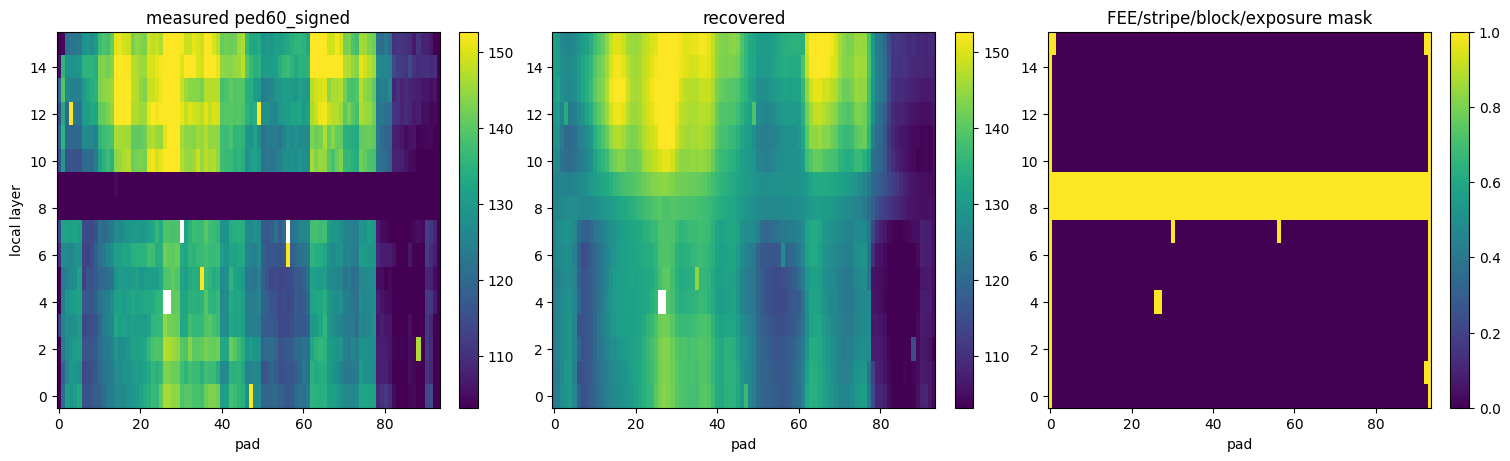

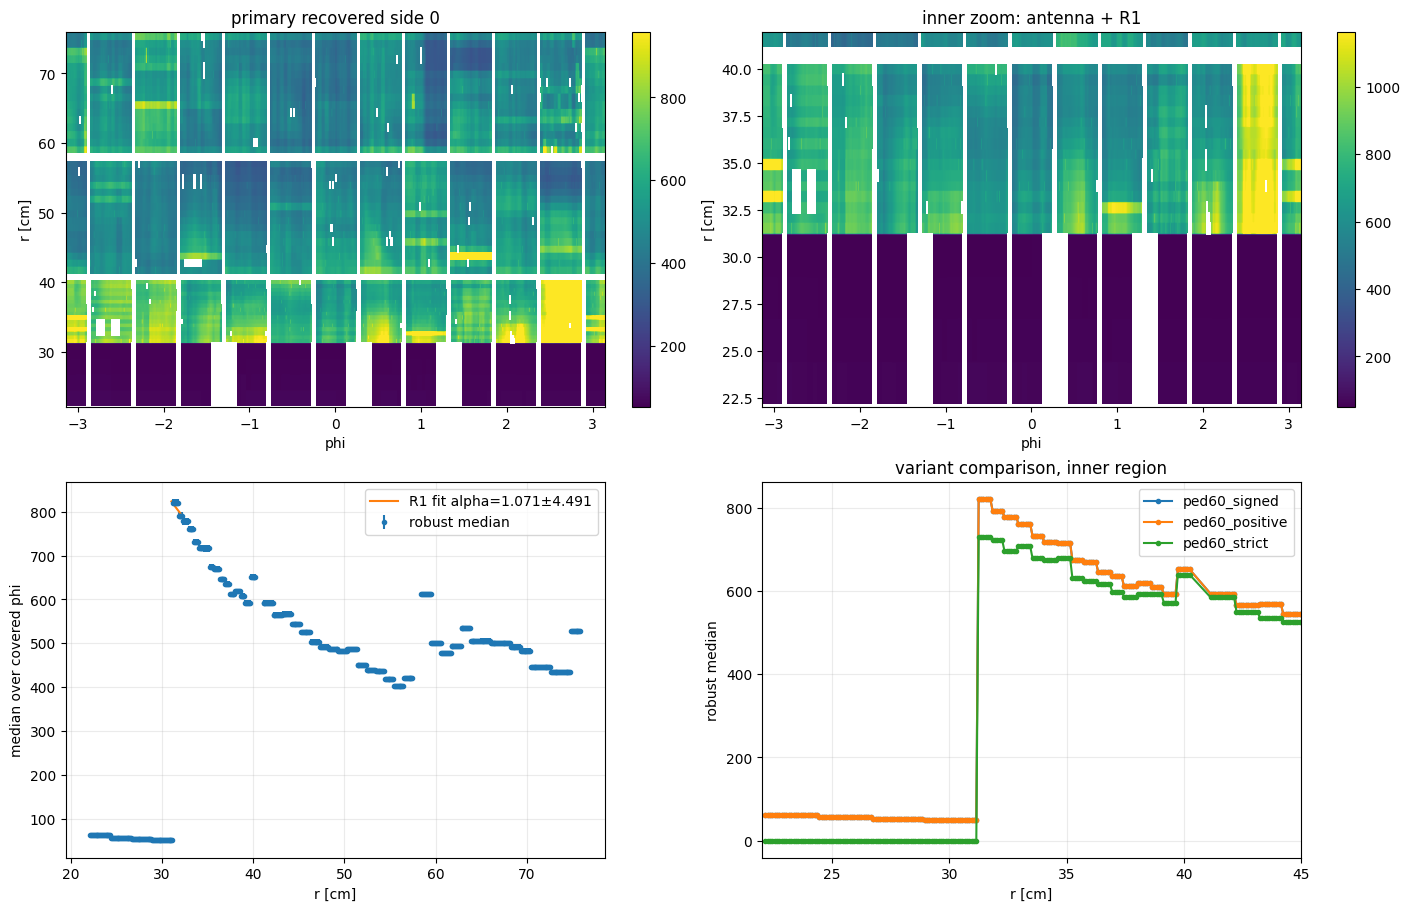

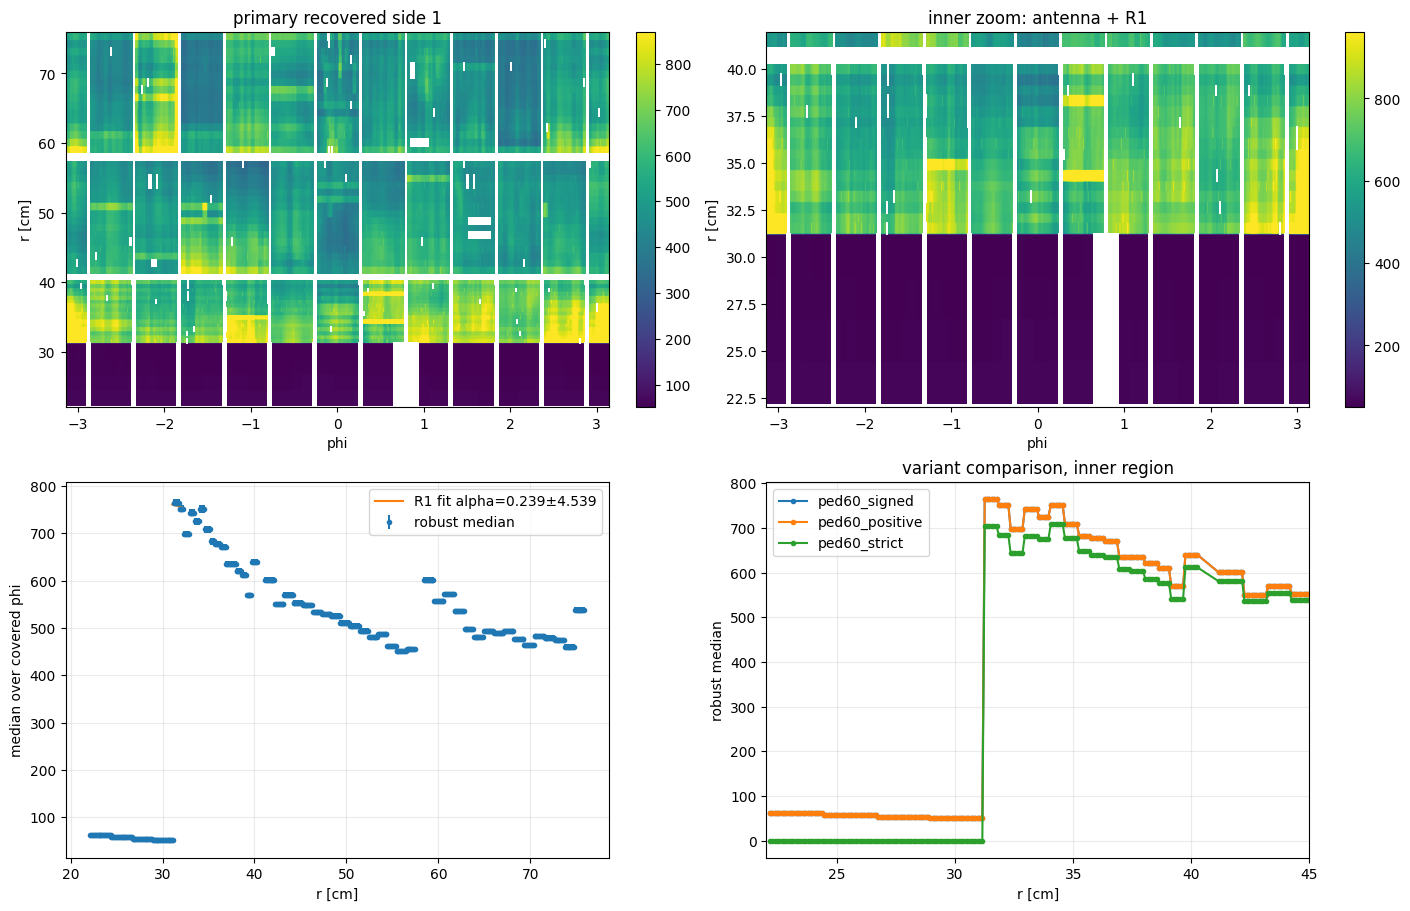

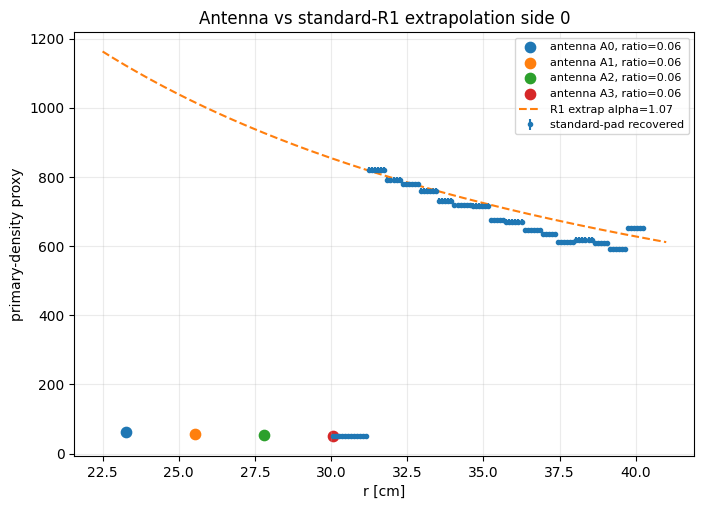

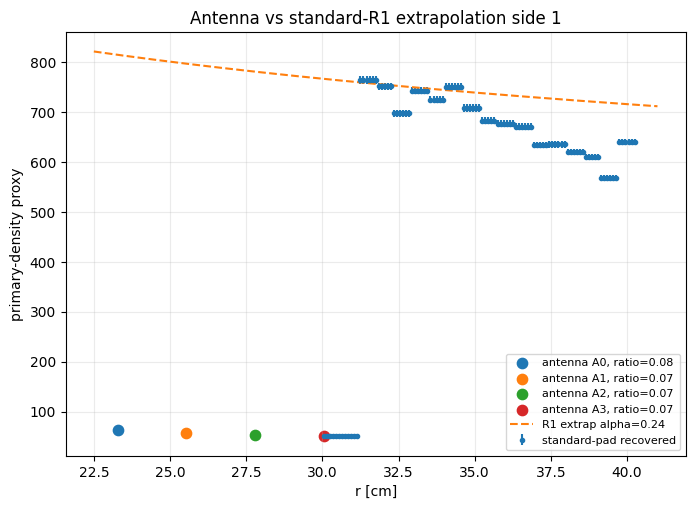

In [11]:

import matplotlib.pyplot as plt

QA_EXAMPLE=(0,0,0)  # side,module,sector

def finite_limits(a,qlo=2,qhi=98):
    v=np.asarray(a,float)
    v=v[np.isfinite(v)]
    if not len(v):
        return None,None
    return tuple(np.percentile(v,[qlo,qhi]))

def plot_native_qa(side,module,sector,variant=MAIN_VARIANT):
    key=(side,module,sector)
    measured=native_products[variant][0][key]
    recovered=native_products[variant][1][key]
    m=auto_masks[key]
    mask=(m["fee"]|m["stripe"]|m["block"]|m["low_exposure"]).astype(float)

    lo,hi=finite_limits(recovered)
    fig,ax=plt.subplots(1,3,figsize=(15,4.5),constrained_layout=True)
    im=ax[0].imshow(measured,aspect="auto",origin="lower",vmin=lo,vmax=hi)
    ax[0].set_title(f"measured {variant}")
    ax[0].set_xlabel("pad"); ax[0].set_ylabel("local layer")
    fig.colorbar(im,ax=ax[0])

    im=ax[1].imshow(recovered,aspect="auto",origin="lower",vmin=lo,vmax=hi)
    ax[1].set_title("recovered")
    ax[1].set_xlabel("pad")
    fig.colorbar(im,ax=ax[1])

    im=ax[2].imshow(mask,aspect="auto",origin="lower",vmin=0,vmax=1)
    ax[2].set_title("FEE/stripe/block/exposure mask")
    ax[2].set_xlabel("pad")
    fig.colorbar(im,ax=ax[2])

    path=QA_PLOT_DIR/f"native_s{side}_R{module+1}_sec{sector:02d}_{variant}.png"
    fig.savefig(path,dpi=150)
    print("saved",path)
    print(" fee regions:",m["fee_regions"])
    print(" stripe details:",m["stripe_details"])
    print(" block details:",m["block_details"])
    return fig

def plot_global_qa(side,variant=MAIN_VARIANT,mode="recovered",quantity="primary"):
    item=combined_maps[variant][mode][side]
    a=item[quantity]
    lo,hi=finite_limits(a)
    p,e,n=profile_cache[(variant,mode,quantity,side)]
    fit=fit_powerlaw_profile(r_centers,p,e)

    fig,ax=plt.subplots(2,2,figsize=(14,9),constrained_layout=True)

    im=ax[0,0].imshow(
        a,aspect="auto",origin="lower",
        extent=[PHI_MIN,PHI_MAX,r_edges[0],r_edges[-1]],
        vmin=lo,vmax=hi
    )
    ax[0,0].set_title(f"{quantity} {mode} side {side}")
    ax[0,0].set_xlabel("phi"); ax[0,0].set_ylabel("r [cm]")
    fig.colorbar(im,ax=ax[0,0])

    inner=(r_centers>=22)&(r_centers<=42)
    ai=a[inner]
    ilo,ihi=finite_limits(ai)
    im=ax[0,1].imshow(
        ai,aspect="auto",origin="lower",
        extent=[PHI_MIN,PHI_MAX,r_edges[np.where(inner)[0][0]],
                r_edges[np.where(inner)[0][-1]+1]],
        vmin=ilo,vmax=ihi
    )
    ax[0,1].set_title("inner zoom: antenna + R1")
    ax[0,1].set_xlabel("phi"); ax[0,1].set_ylabel("r [cm]")
    fig.colorbar(im,ax=ax[0,1])

    good=np.isfinite(p)
    ax[1,0].errorbar(r_centers[good],p[good],yerr=e[good],fmt=".",label="robust median")
    if np.isfinite(fit["alpha"]):
        ax[1,0].plot(fit["r"],fit["fit"],
                     label=f"R1 fit alpha={fit['alpha']:.3f}±{fit['alpha_err']:.3f}")
    ax[1,0].set_xlabel("r [cm]")
    ax[1,0].set_ylabel("median over covered phi")
    ax[1,0].legend()
    ax[1,0].grid(True,alpha=0.25)

    for v in ("ped60_signed","ped60_positive","ped60_strict"):
        pp,ee,nn=profile_cache[(v,mode,quantity,side)]
        gg=np.isfinite(pp)
        ax[1,1].plot(r_centers[gg],pp[gg],".-",label=v)
    ax[1,1].set_xlim(22,45)
    ax[1,1].set_xlabel("r [cm]")
    ax[1,1].set_ylabel("robust median")
    ax[1,1].set_title("variant comparison, inner region")
    ax[1,1].legend()
    ax[1,1].grid(True,alpha=0.25)

    path=QA_PLOT_DIR/f"global_{quantity}_{mode}_side{side}_{variant}.png"
    fig.savefig(path,dpi=150)
    print("saved",path)
    return fig

def plot_antenna_extrapolation(side):
    fit,p,e,pred=standard_r1_prediction(side)
    fig,ax=plt.subplots(figsize=(8,5.5))
    good=np.isfinite(p)&(r_centers>=30)&(r_centers<=41)
    ax.errorbar(r_centers[good],p[good],yerr=e[good],fmt=".",label="standard-pad recovered")

    rr=[]; yy=[]
    for ring,(rval,med,expected,ratio) in enumerate(antenna_ring_summary[side]):
        rr.append(rval); yy.append(med)
        ax.scatter([rval],[med],s=55,label=f"antenna A{ring}, ratio={ratio:.2f}")

    xr=np.linspace(22.5,41,250)
    if np.isfinite(fit["alpha"]):
        yr=fit["rho_ref"]*(fit["r_ref"]/xr)**fit["alpha"]
        ax.plot(xr,yr,"--",label=f"R1 extrap alpha={fit['alpha']:.2f}")

    ax.set_xlabel("r [cm]")
    ax.set_ylabel("primary-density proxy")
    ax.set_title(f"Antenna vs standard-R1 extrapolation side {side}")
    ax.grid(True,alpha=0.25)
    ax.legend(fontsize=8)
    path=QA_PLOT_DIR/f"antenna_vs_r1_side{side}.png"
    fig.savefig(path,dpi=150,bbox_inches="tight")
    print("saved",path)
    return fig

if not IS_BATCH_CHILD:
    plot_native_qa(*QA_EXAMPLE)
    plot_global_qa(0)
    plot_global_qa(1)
    plot_antenna_extrapolation(0)
    plot_antenna_extrapolation(1)



## 10. Save ROOT products and per-run summary

Unlike v21, coverage and unstable-fraction maps are written alongside the density maps. The dedicated radial profile histograms are the recommended radial QA objects.


In [14]:

def array_to_th2(name,title,a):
    h=root.TH2D(
        name,title,
        len(phi_edges)-1,array("d",phi_edges),
        len(r_edges)-1,array("d",r_edges)
    )
    h.SetDirectory(0)
    for ir in range(a.shape[0]):
        for ip in range(a.shape[1]):
            v=a[ir,ip]
            h.SetBinContent(ip+1,ir+1,float(v) if np.isfinite(v) else 0.0)
    return h

def profile_to_th1(name,title,p,e=None):
    h=root.TH1D(name,title,len(r_edges)-1,array("d",r_edges))
    h.SetDirectory(0)
    for ir,v in enumerate(p):
        if np.isfinite(v):
            h.SetBinContent(ir+1,float(v))
            if e is not None and np.isfinite(e[ir]):
                h.SetBinError(ir+1,float(e[ir]))
    return h

fout=root.TFile(str(OUTPUT_ROOT),"RECREATE")

for variant in DC_VARIANTS:
    for mode in ("measured","recovered"):
        for side in range(2):
            item=combined_maps[variant][mode][side]
            for quantity in ("dc","primary"):
                array_to_th2(
                    f"h_{quantity}_density_{mode}_rphi_{variant}_side{side}",
                    f"{quantity} density {mode} {variant} side {side};#phi;r [cm]",
                    item[quantity]
                ).Write()

                p,e,n=profile_cache[(variant,mode,quantity,side)]
                profile_to_th1(
                    f"h_{quantity}_profile_r_{mode}_{variant}_side{side}",
                    f"{quantity} robust radial profile {mode} {variant} side {side};r [cm];median over covered #phi",
                    p,e
                ).Write()

            array_to_th2(
                f"h_coverage_{mode}_{variant}_side{side}",
                f"coverage {mode} {variant} side {side};#phi;r [cm]",
                item["coverage"]
            ).Write()

            if mode=="recovered":
                array_to_th2(
                    f"h_repair_fraction_rphi_{variant}_side{side}",
                    f"repair fraction {variant} side {side};#phi;r [cm]",
                    item["repair_fraction"]
                ).Write()
                array_to_th2(
                    f"h_unstable_fraction_rphi_{variant}_side{side}",
                    f"unstable fraction {variant} side {side};#phi;r [cm]",
                    item["unstable_fraction"]
                ).Write()
                array_to_th2(
                    f"h_antenna_mask_rphi_{variant}_side{side}",
                    f"antenna coverage {variant} side {side};#phi;r [cm]",
                    item["antenna_mask"].astype(float)
                ).Write()

# Backward-friendly main aliases.
for side in range(2):
    main=combined_maps[MAIN_VARIANT]["recovered"][side]
    array_to_th2(
        f"h_dc_density_clean_rphi_side{side}",
        f"Recovered DC density side {side};#phi;r [cm]",
        main["dc"]
    ).Write()
    array_to_th2(
        f"h_primary_density_clean_rphi_side{side}",
        f"Recovered primary-density proxy side {side};#phi;r [cm]",
        main["primary"]
    ).Write()

hgem=root.TH1D("h_gem_current","R1 GEM current/load;side;load current",2,-0.5,1.5)
hgem.GetXaxis().SetBinLabel(1,"South")
hgem.GetXaxis().SetBinLabel(2,"North")
for s in range(2):
    hgem.SetBinContent(s+1,float(RUN_GEM_CURRENT[s]))
hgem.Write()

hexp=root.TH1D("h_live_frame_slots","Synchronized DC live exposure;side;frame slots",2,-0.5,1.5)
for s in range(2):
    hexp.SetBinContent(s+1,float(LIVE_FRAME_SLOTS[s]))
hexp.Write()

# Alpha summary
halpha=root.TH2D("h_alpha_summary",
                 "R1 alpha summary;side;variant index",
                 2,-0.5,1.5,len(DC_VARIANTS),-0.5,len(DC_VARIANTS)-0.5)
for iv, v in enumerate(DC_VARIANTS):
    halpha.GetYaxis().SetBinLabel(iv+1, v)

    for side in range(2):
        sel = alpha_df[
            (alpha_df["variant"] == v) &
            (alpha_df["mode"] == "recovered") &
            (alpha_df["quantity"] == "primary") &
            (alpha_df["side"] == side)
        ]

        if len(sel) == 0:
            print(f"WARNING: no alpha row for {v}, side {side}")
            continue

        row = sel.iloc[0]

        halpha.SetBinContent(side+1, iv+1, float(row["alpha"]))

        if np.isfinite(row["alpha_err"]):
            halpha.SetBinError(
                halpha.GetBin(side+1, iv+1),
                float(row["alpha_err"])
            )
halpha.Write()

# Antenna/R1 ratio metadata
har=root.TH2D("h_antenna_over_r1_extrap",
              "Antenna / standard-R1 extrapolation;side;antenna ring",
              2,-0.5,1.5,4,-0.5,3.5)
for side in range(2):
    for ring in range(4):
        rr=antenna_ratio_df[(antenna_ratio_df.side==side)&(antenna_ratio_df.ring==ring)]
        if len(rr):
            har.SetBinContent(side+1,ring+1,float(rr.iloc[0].antenna_over_r1_extrap))
har.Write()

root.TNamed("dc_main_variant",MAIN_VARIANT).Write()
root.TNamed("dc_defect_variant",DEFECT_VARIANT).Write()
root.TNamed(
    "dc_geometry_definition",
    "v22: standard R1/R2/R3 radial pitch derived separately within each module; "
    "antenna radial pitch derived separately from the four antenna rings; "
    "global phi uses the current IdealPadMap side/sector transform."
).Write()
root.TNamed(
    "dc_antenna_definition",
    "Antenna DC is reconstructed by integrating coarse global DC bins over each mapped "
    "antenna collection cell. No normal 48-layer gain correction is applied."
).Write()
root.TNamed(
    "dc_profile_definition",
    "Radial profiles are medians over covered finite phi bins. Do not use raw TH2 ProjectionY "
    "as a substitute for these profiles."
).Write()

fout.Close()

# Per-run scalar summary for batch aggregation.
summary_rows=[]
for side in range(2):
    for variant in DC_VARIANTS:
        sel = alpha_df[
            (alpha_df["variant"] == variant) &
            (alpha_df["mode"] == "recovered") &
            (alpha_df["quantity"] == "primary") &
            (alpha_df["side"] == side)
        ]
        
        if len(sel) == 0:
            print(f"WARNING: missing alpha summary for {variant}, side {side}")
            continue
        
        ar = sel.iloc[0]

        # stable normal-pad DC metric over 31-76 cm
        p,e,n=profile_cache[(variant,"recovered","dc",side)]
        good=np.isfinite(p)&(r_centers>=31)&(r_centers<=76)
        dc_metric=float(np.nanmedian(p[good])) if np.any(good) else np.nan

        row={
            "run":RUN_NUMBER,
            "side":side,
            "variant":variant,
            "gem_current":RUN_GEM_CURRENT[side],
            "live_frame_slots":LIVE_FRAME_SLOTS[side],
            "dc_density_metric":dc_metric,
            "alpha_primary":float(ar.alpha),
            "alpha_primary_err":float(ar.alpha_err),
        }
        for ring in range(4):
            rr=antenna_ratio_df[
                (antenna_ratio_df.side==side)&
                (antenna_ratio_df.ring==ring)
            ]
            row[f"antenna_ratio_A{ring}"]=float(rr.iloc[0].antenna_over_r1_extrap) if len(rr) else np.nan
        summary_rows.append(row)

summary_df=pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_SUMMARY,index=False)

print("Wrote",OUTPUT_ROOT)
print("Wrote",OUTPUT_SUMMARY)


Wrote output_dc/TPC_DC_primary_density_v22_run80858.root
Wrote output_dc/TPC_DC_summary_v22_run80858.csv


Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasing order
Error in <TAxis::TAxis::Set>: bins must be in increasin


## 11. Parallel multi-run production

The parent notebook discovers merged Takao sample files with:

```text
dc_samples_run*/dc_run*_3samples.root
```

and executes this notebook independently for each run. Each child writes a unique ROOT file and CSV summary. The parent then builds the cross-run plots.

Set, for example:

```bash
export TPC_DC_BATCH_WORKERS=6
```

before starting Jupyter if you want to change the concurrency.


In [15]:

def discover_batch_inputs(pattern=BATCH_INPUT_GLOB):
    files=sorted(Path(".").glob(pattern))
    return [str(p.resolve()) for p in files]

def run_batch(input_files=None, notebook=NOTEBOOK_FILE, max_workers=BATCH_MAX_WORKERS):
    if IS_BATCH_CHILD:
        print("Batch child: production-only execution")
        return []

    if input_files is None:
        input_files=discover_batch_inputs()

    if not input_files:
        print("No batch inputs found with:",BATCH_INPUT_GLOB)
        return []

    notebook=Path(notebook).resolve()
    if not notebook.exists():
        raise FileNotFoundError(
            f"Notebook not found: {notebook}. "
            "Set TPC_DC_NOTEBOOK if the filename/path differs."
        )

    print(f"Launching {len(input_files)} runs with max_workers={max_workers}")

    def run_one(infile):
        infile=Path(infile).resolve()
        run=infer_run(infile)
        tag=f"run{run}" if run>0 else infile.stem
        env=os.environ.copy()
        env["TPC_DC_INPUT"]=str(infile)
        env["TPC_DC_TAG"]=tag
        env["TPC_DC_BATCH_CHILD"]="1"
        env["TPC_DC_NOTEBOOK"]=str(notebook)

        executed=(OUTPUT_DIR/f"executed_v22_{tag}.ipynb").resolve()
        cmd=[
            "jupyter","nbconvert","--to","notebook","--execute",str(notebook),
            "--output",executed.name,
            "--output-dir",str(executed.parent),
            "--ExecutePreprocessor.timeout=-1",
        ]

        print(f"[START] {tag}: {infile}")
        result=subprocess.run(cmd,env=env,text=True,capture_output=True)
        if result.returncode:
            raise RuntimeError(
                f"{tag} failed (exit {result.returncode})\n"
                f"STDOUT:\n{result.stdout}\nSTDERR:\n{result.stderr}"
            )
        print(f"[DONE ] {tag}")
        return run

    produced=[]
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures={pool.submit(run_one,f):f for f in input_files}
        for future in as_completed(futures):
            try:
                produced.append(future.result())
            except Exception as exc:
                print("[FAIL]",futures[future],exc)
                raise

    produced=sorted(produced)
    print(f"Finished {len(produced)}/{len(input_files)} runs:",produced)
    return produced

# Run this manually after validating one run:
# produced_runs = run_batch()



## 12. Cross-run comparison: DC density vs GEM current and other diagnostics

Run this after `run_batch()` finishes. It reads the per-run CSV summaries and produces:

- DC density vs GEM current;
- primary R1 α vs GEM current;
- antenna/R1-extrapolation ratio vs GEM current for all four antenna rings;
- DC-density ratio to a reference run;
- CSV table with all scalar observables.

This is the DC replacement for the v20 streaming-ADC/GEM-current comparison.


In [16]:

def load_batch_summaries():
    paths=sorted(OUTPUT_DIR.glob("TPC_DC_summary_v22_run*.csv"))
    frames=[]
    for p in paths:
        try:
            frames.append(pd.read_csv(p))
        except Exception as exc:
            print("Skipping",p,exc)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames,ignore_index=True).sort_values(["run","side","variant"])

def fit_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float)
    good=np.isfinite(x)&np.isfinite(y)
    if np.count_nonzero(good)<2:
        return np.nan,np.nan
    p=np.polyfit(x[good],y[good],1)
    return float(p[0]),float(p[1])

def run_comparisons(variant=MAIN_VARIANT):
    df=load_batch_summaries()
    if df.empty:
        print("No v22 batch summaries found in",OUTPUT_DIR)
        return None

    d=df[df.variant==variant].copy()
    outcsv=OUTPUT_DIR/f"TPC_DC_crossrun_v22_{variant}.csv"
    d.to_csv(outcsv,index=False)
    print("Wrote",outcsv)

    # 1) DC density vs GEM current
    fig,ax=plt.subplots(figsize=(8,6))
    for side in range(2):
        s=d[d.side==side]
        ax.errorbar(s.gem_current,s.dc_density_metric,fmt="o",label=f"side {side}")
        slope,intercept=fit_line(s.gem_current,s.dc_density_metric)
        good=np.isfinite(s.gem_current)&np.isfinite(s.dc_density_metric)
        if np.count_nonzero(good)>=2:
            xx=np.linspace(s.gem_current[good].min(),s.gem_current[good].max(),100)
            ax.plot(xx,intercept+slope*xx,"--",
                    label=f"side {side} fit slope={slope:.4g}")
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("stable recovered DC density metric")
    ax.set_title(f"DC density vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend()
    p=OUTPUT_DIR/f"dc_density_vs_gem_current_v22_{variant}.png"
    fig.savefig(p,dpi=160,bbox_inches="tight")
    print("saved",p)

    # 2) alpha vs GEM current
    fig,ax=plt.subplots(figsize=(8,6))
    for side in range(2):
        s=d[d.side==side]
        ax.errorbar(
            s.gem_current,s.alpha_primary,
            yerr=s.alpha_primary_err,fmt="o",label=f"side {side}"
        )
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("standard-R1 primary alpha")
    ax.set_title(f"R1 alpha vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend()
    p=OUTPUT_DIR/f"alpha_vs_gem_current_v22_{variant}.png"
    fig.savefig(p,dpi=160,bbox_inches="tight")
    print("saved",p)

    # 3) antenna / R1 extrapolation vs GEM current
    fig,ax=plt.subplots(figsize=(9,6))
    for side in range(2):
        s=d[d.side==side]
        for ring in range(4):
            col=f"antenna_ratio_A{ring}"
            ax.plot(s.gem_current,s[col],"o-",label=f"s{side} A{ring}")
    ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("R1 GEM current/load")
    ax.set_ylabel("antenna / standard-R1 extrapolation")
    ax.set_title(f"Antenna response vs GEM current ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend(ncol=2,fontsize=8)
    p=OUTPUT_DIR/f"antenna_ratio_vs_gem_current_v22_{variant}.png"
    fig.savefig(p,dpi=160,bbox_inches="tight")
    print("saved",p)

    # 4) DC metric ratio to reference run
    fig,ax=plt.subplots(figsize=(8,6))
    for side in range(2):
        s=d[d.side==side].copy()
        ref=s[s.run==REFERENCE_RUN]
        if ref.empty:
            print(f"Reference run {REFERENCE_RUN} missing for side {side}; ratio plot skipped for this side")
            continue
        refv=float(ref.iloc[0].dc_density_metric)
        ratio=s.dc_density_metric/refv
        ax.plot(s.run,ratio,"o-",label=f"side {side}")
    ax.axhline(1.0,ls="--",lw=1)
    ax.set_xlabel("run")
    ax.set_ylabel(f"DC density / run {REFERENCE_RUN}")
    ax.set_title(f"Run/reference DC-density ratio ({variant})")
    ax.grid(True,alpha=0.25)
    ax.legend()
    p=OUTPUT_DIR/f"dc_density_ratio_to_{REFERENCE_RUN}_v22_{variant}.png"
    fig.savefig(p,dpi=160,bbox_inches="tight")
    print("saved",p)

    return d

# Run manually after batch production:
# comparison_df = run_comparisons("ped60_signed")
# comparison_df_pos = run_comparisons("ped60_positive")



## Recommended validation order

Before using the map in PHGarfield:

1. Run one file and compare the printed α for `ped60_signed`, `ped60_positive`, and `ped60_strict`.
2. Inspect native FEE/stripe recovery in several bad sectors.
3. Check the inner zoom and the antenna-vs-R1-extrapolation canvases.
4. Run all Takao files in parallel.
5. Inspect `dc_density_vs_gem_current`, `alpha_vs_gem_current`, and `antenna_ratio_vs_gem_current`.
6. Only if the antenna/R1 ratio is stable versus GEM current should a dedicated antenna response scale be considered.
7. For the final antenna-quality version, extend the C++ preprocessing to write native antenna charge/exposure histograms rather than reconstructing them from the global coarse map.
